In [1]:
import pandas as pd
df = pd.read_csv('hn_raw.csv')

In [2]:
df

,id,title,score,num_comments,created_utc,author,url,is_ask_hn
0,48989551,Vixen 0.3 – fork of ratpoison (winman) goes ba...,1,1,1784622143,icmpkitty,https://codeberg.org/spidervixn/vixen,False
1,48989537,[LITERARY CRITICISM] The 'Screwfly Solution' S...,1,0,1784622008,barry-cotter,https://gwern.net/screwfly,False
2,48989529,Show HN: A BIOS-style terminal for observing a...,1,1,1784621902,Speykey,https://speykye.github.io/persistent-world-obs...,False
3,48989518,Judge halts Paramount's $111B purchase of Warn...,3,0,1784621821,rbanffy,https://arstechnica.com/tech-policy/2026/07/ju...,False
4,48989504,Did China just beat Intel?,3,0,1784621581,xnhbx,https://twitter.com/SemiAnalysis_/status/20792...,False
...,...,...,...,...,...,...,...,...
81055,47869351,X is going to let Grok curate your timeline,2,0,1776892344,omer_k,https://www.theverge.com/tech/917113/x-ai-grok...,False
81056,47869343,The opportunity is in building ethical softwar...,3,0,1776892304,sailorganymede,https://bhurghundii.substack.com/p/the-opportu...,False
81057,47869331,Bolt AI builder: Create apps and websites by c...,1,0,1776892253,doener,https://bolt.new,False
81058,47869330,My GLM-5.1 coding agent scored 94.3% on LiveCo...,5,0,1776892237,univence,NaN,False


In [3]:
df1=pd.read_csv('hn_features.csv')

In [4]:
df1


,id,title,score,num_comments,created_utc,author,url,is_ask_hn,created_dt,hour_of_day,day_of_week,title_len,title_word_count,has_question_mark,has_number,has_url,log_score
0,48989551,Vixen 0.3 – fork of ratpoison (winman) goes ba...,1,1,1784622143,icmpkitty,https://codeberg.org/spidervixn/vixen,False,2026-07-21 08:22:23,8,1,76,15,0,1,1,0.693147
1,48989537,[LITERARY CRITICISM] The 'Screwfly Solution' S...,1,0,1784622008,barry-cotter,https://gwern.net/screwfly,False,2026-07-21 08:20:08,8,1,67,7,0,0,1,0.693147
2,48989529,Show HN: A BIOS-style terminal for observing a...,1,1,1784621902,Speykey,https://speykye.github.io/persistent-world-obs...,False,2026-07-21 08:18:22,8,1,77,11,0,0,1,0.693147
3,48989518,Judge halts Paramount's $111B purchase of Warn...,3,0,1784621821,rbanffy,https://arstechnica.com/tech-policy/2026/07/ju...,False,2026-07-21 08:17:01,8,1,75,13,0,1,1,1.386294
4,48989504,Did China just beat Intel?,3,0,1784621581,xnhbx,https://twitter.com/SemiAnalysis_/status/20792...,False,2026-07-21 08:13:01,8,1,26,5,1,0,1,1.386294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81055,47869351,X is going to let Grok curate your timeline,2,0,1776892344,omer_k,https://www.theverge.com/tech/917113/x-ai-grok...,False,2026-04-22 21:12:24,21,2,43,9,0,0,1,1.098612
81056,47869343,The opportunity is in building ethical softwar...,3,0,1776892304,sailorganymede,https://bhurghundii.substack.com/p/the-opportu...,False,2026-04-22 21:11:44,21,2,73,11,0,0,1,1.386294
81057,47869331,Bolt AI builder: Create apps and websites by c...,1,0,1776892253,doener,https://bolt.new,False,2026-04-22 21:10:53,21,2,61,11,0,0,1,0.693147
81058,47869330,My GLM-5.1 coding agent scored 94.3% on LiveCo...,5,0,1776892237,univence,NaN,False,2026-04-22 21:10:37,21,2,68,10,0,1,0,1.791759


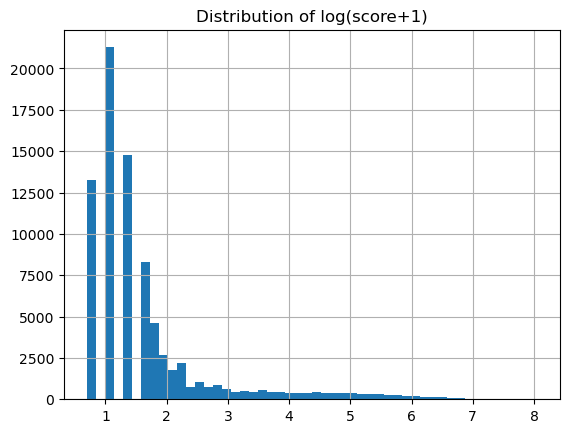

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("hn_features.csv")
df["log_score"].hist(bins=50)
plt.title("Distribution of log(score+1)")
plt.show()

# The graph below shows us that the scores for most of the posts or submissions are between the units 1 and 2. 
# There are very few posts or submissions which get this score above 4 or 5 or even 6
# By this we understand that most of the posts get a very low score or maybe visibility in the sense 

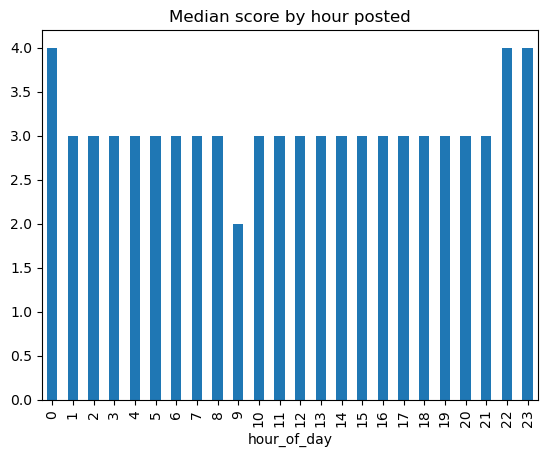

In [7]:
df.groupby("hour_of_day")["score"].median().plot(kind="bar")
plt.title("Median score by hour posted")
plt.show()

# By the graph below we get to know that most of the posts which have submission time or 
# which are submitted at the time around in the night between 11:00 and 12:00 or even 10:00 get more scores. 

In [9]:
!pip install lightgbm

  Using cached lightgbm-4.7.0-py3-none-win_amd64.whl.metadata (18 kB)
Using cached lightgbm-4.7.0-py3-none-win_amd64.whl (1.4 MB)


In [10]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import joblib

df = pd.read_csv("hn_features.csv")

features = ["hour_of_day", "day_of_week", "title_len", "title_word_count",
            "has_question_mark", "has_number", "has_url", "is_ask_hn"]
X = df[features]
y = df["log_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = lgb.LGBMRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, preds))

joblib.dump(model, "model.pkl")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003955 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 149
[LightGBM] [Info] Number of data points in the train set: 64848, number of used features: 8
[LightGBM] [Info] Start training from score 1.685607
MAE: 0.7470650818679508


['model.pkl']

In [11]:
import numpy as np
baseline_pred = [y_train.median()] * len(y_test)
print("Baseline MAE:", mean_absolute_error(y_test, baseline_pred))

Baseline MAE: 0.670604789336633


Saved shap_summary.png — open it and see which features matter most.


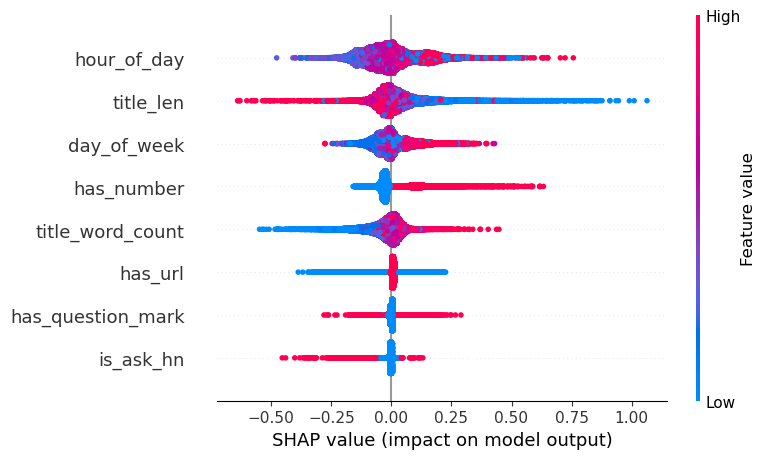

In [13]:
import pandas as pd
import joblib
import shap

df = pd.read_csv("hn_features.csv")
features = ["hour_of_day", "day_of_week", "title_len", "title_word_count",
            "has_question_mark", "has_number", "has_url", "is_ask_hn"]
model = joblib.load("model.pkl")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(df[features])

shap.summary_plot(shap_values, df[features], show=False)
import matplotlib.pyplot as plt
plt.savefig("shap_summary.png", bbox_inches="tight")
print("Saved shap_summary.png — open it and see which features matter most.")

# Looking at the shap we get to know that the features contributing more to the engagement of the post or a submission are:
# - the hour at which it is posted
# - the length of the title of the post that matters
# - and after that we have the particular day of the week it is posted etc.